In [6]:
#Toy Example(MNIST digits):

from keras import layers
from keras import models

#define model
model = models.Sequential()
#define convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
#define convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
#define convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

#Add classfier at the top
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/Users/mihtriii/Documents/GitHub/DAP391m/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Training the convnet on MNIST images
from keras.datasets import mnist
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9071 - loss: 0.2990
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9735 - loss: 0.0876
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9822 - loss: 0.0580
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9859 - loss: 0.0449
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9894 - loss: 0.0340


In [8]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9804 - loss: 0.0666
accuracy: 0.980400025844574


Model: "legacy_seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)


Show diagram:


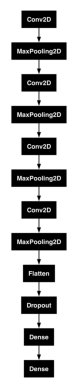

In [27]:
import json
import h5py
from keras import Input, layers, Sequential
from keras.models import load_model as keras_load_model
from keras.utils import plot_model
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def load_legacy_h5_model(path):
    try:
        # Works for modern Keras model files.
        return keras_load_model(path, compile=False)
    except TypeError as exc:
        # Fallback for older H5 Sequential configs that break in Keras 3.
        if "pop expected at most 1 argument" not in str(exc):
            raise

        with h5py.File(path, "r") as f:
            model_config = f.attrs.get("model_config")
            if model_config is None:
                raise ValueError("model_config not found in H5 file")
            if hasattr(model_config, "decode"):
                model_config = model_config.decode("utf-8")
            model_config = json.loads(model_config)

        layer_cfgs = model_config["config"]
        first_cfg = dict(layer_cfgs[0]["config"])
        batch_input_shape = first_cfg.pop("batch_input_shape", None)

        model = Sequential(name="legacy_seq")
        if batch_input_shape is not None:
            model.add(Input(shape=tuple(batch_input_shape[1:])))

        for idx, layer_cfg in enumerate(layer_cfgs):
            cfg = dict(layer_cfg["config"])
            if idx == 0:
                cfg.pop("batch_input_shape", None)
            layer_cls = getattr(layers, layer_cfg["class_name"])
            model.add(layer_cls.from_config(cfg), rebuild=False)

        if batch_input_shape is not None:
            model.build(tuple(batch_input_shape))

        model.load_weights(path)
        return model

# load model from file (we don't create model from scratch)
model = load_legacy_h5_model('./cats_and_dogs.h5')
model.summary()

# Save model diagram in file
plot_model(model, to_file='model.png')

# Show diagram
print("\nShow diagram:")
img = mpimg.imread('model.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Tensor shape: (1, 150, 150, 3)


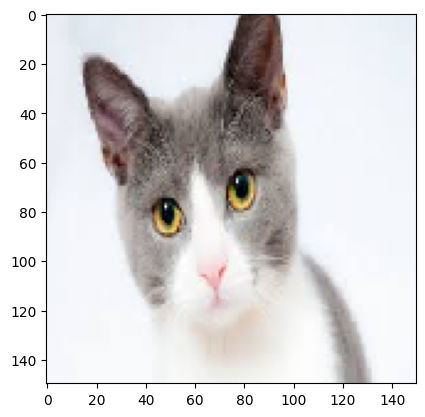

In [29]:
#load image
img_path = 'cat2.png'
from keras.preprocessing import image
import numpy as np
img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print("Tensor shape:",img_tensor.shape)

#Show image
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

In [32]:
from keras import Input, models

probe_input = Input(shape=(150, 150, 3))
x = probe_input
layer_outputs = []

for layer in model.layers[:8]:
    x = layer(x)
    layer_outputs.append(x)

activation_model = models.Model(inputs=probe_input, outputs=layer_outputs)
activations = activation_model.predict(img_tensor, verbose=0)
first_layer_activation = activations[0]


In my case the forth channel detects diagonal edges.
But your result can differ while specific filters learned by CNN are not deterministic.


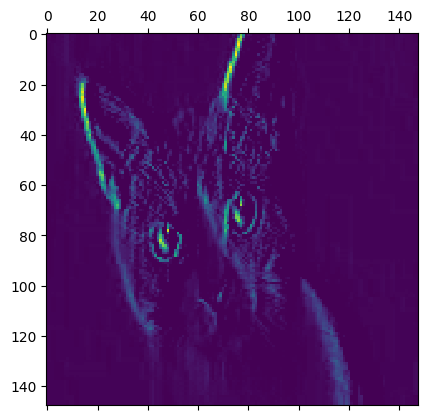

In [33]:
#Visualizing the fourth channel
import matplotlib.pyplot as plt
plt.matshow(first_layer_activation[0, :, :, 4], cmap='viridis')
print("\nIn my case the forth channel detects diagonal edges.\nBut your result can differ while specific filters learned by CNN are not deterministic.")

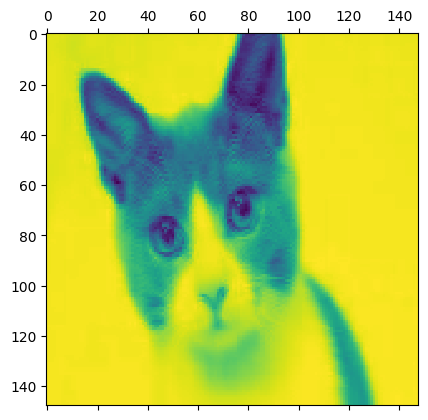

In [34]:
# Seventh channel of the activation of the first layer on the test cat
plt.matshow(first_layer_activation[0, :, :, 7], cmap='viridis')

/var/folders/3r/ccsd6s3j4nxfpldptm6bgghr0000gn/T/ipykernel_18727/3299126685.py:23: RuntimeWarning: invalid value encountered in divide
  channel_image /= channel_image.std()
/var/folders/3r/ccsd6s3j4nxfpldptm6bgghr0000gn/T/ipykernel_18727/3299126685.py:26: RuntimeWarning: invalid value encountered in cast
  channel_image = np.clip(channel_image, 0, 255).astype('uint8')


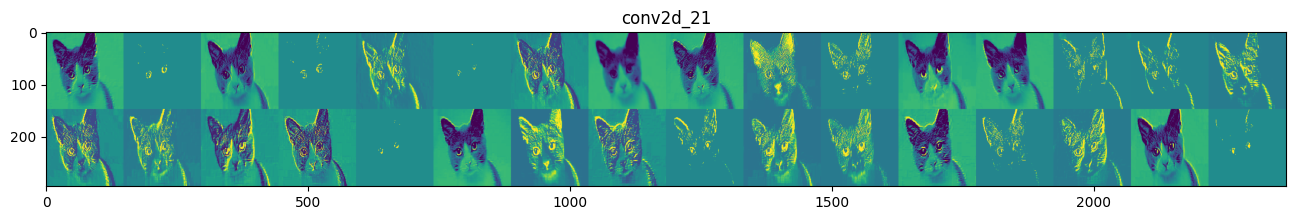

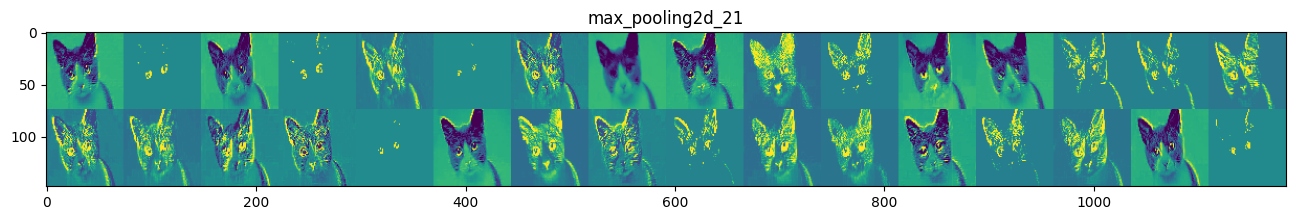

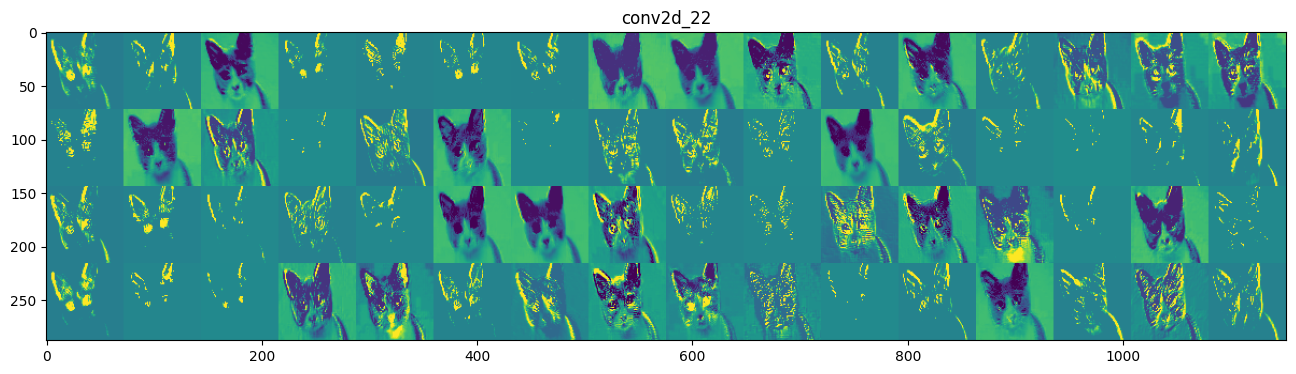

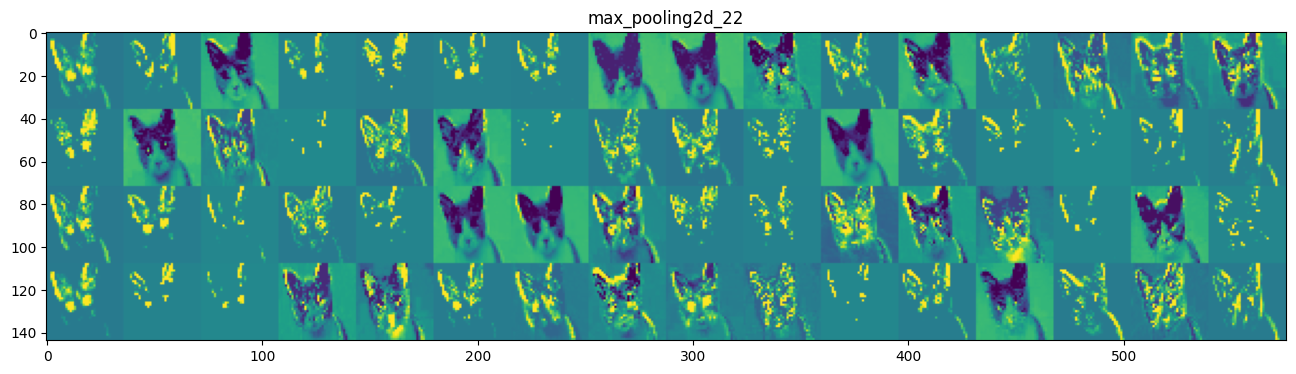

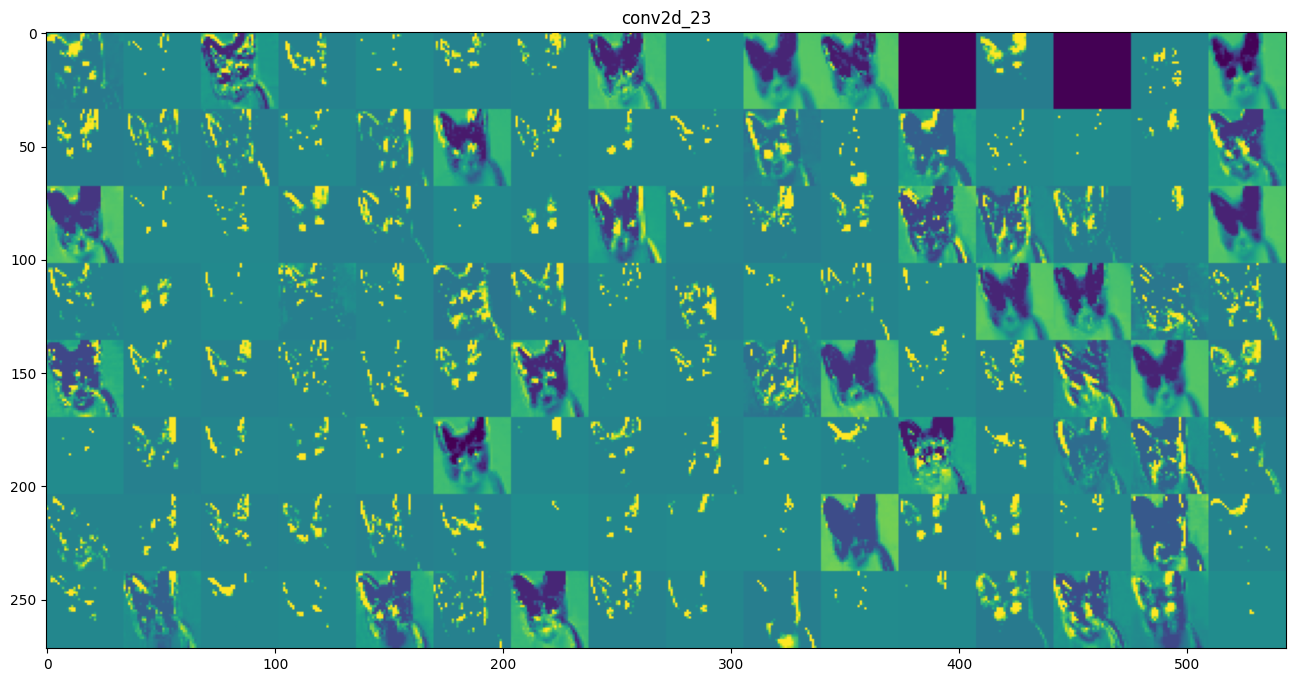

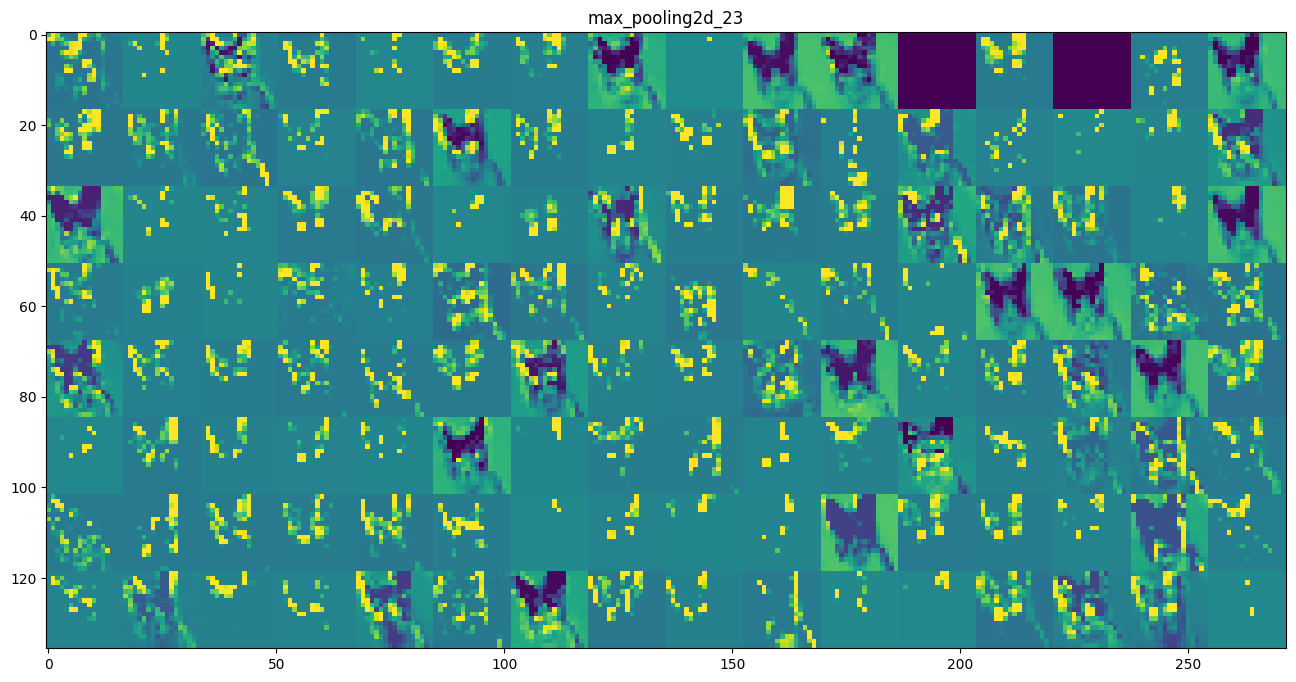

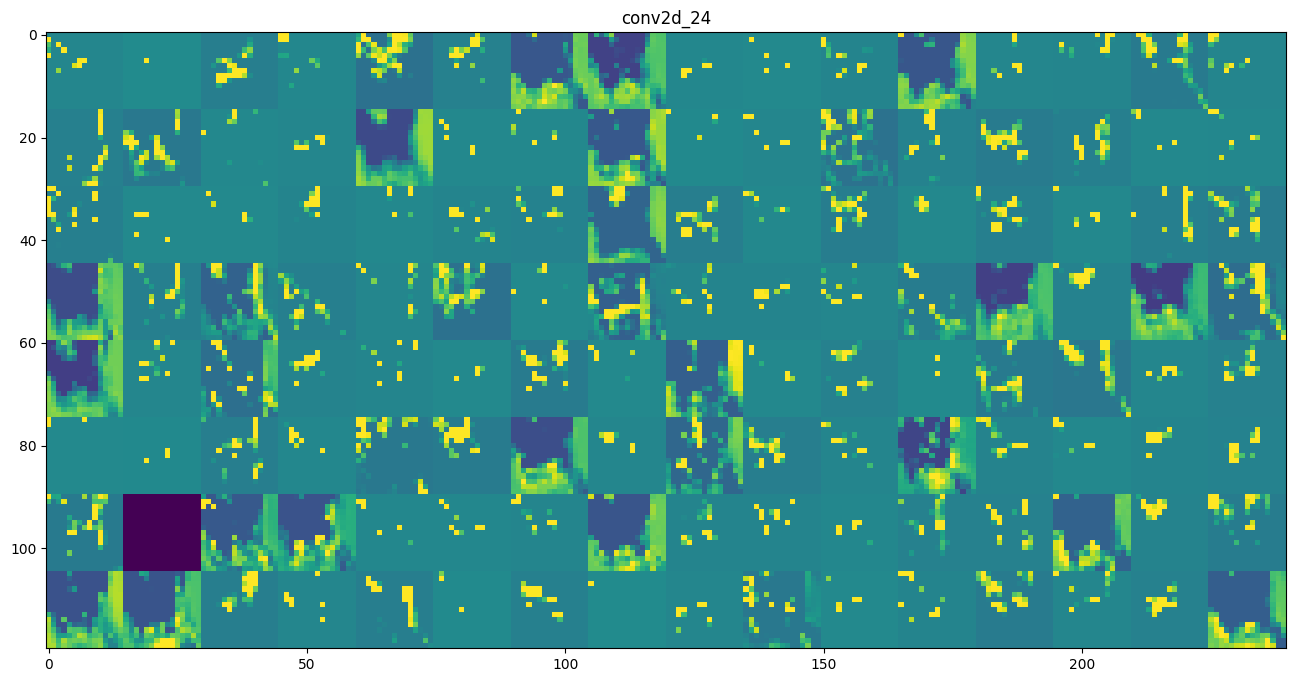

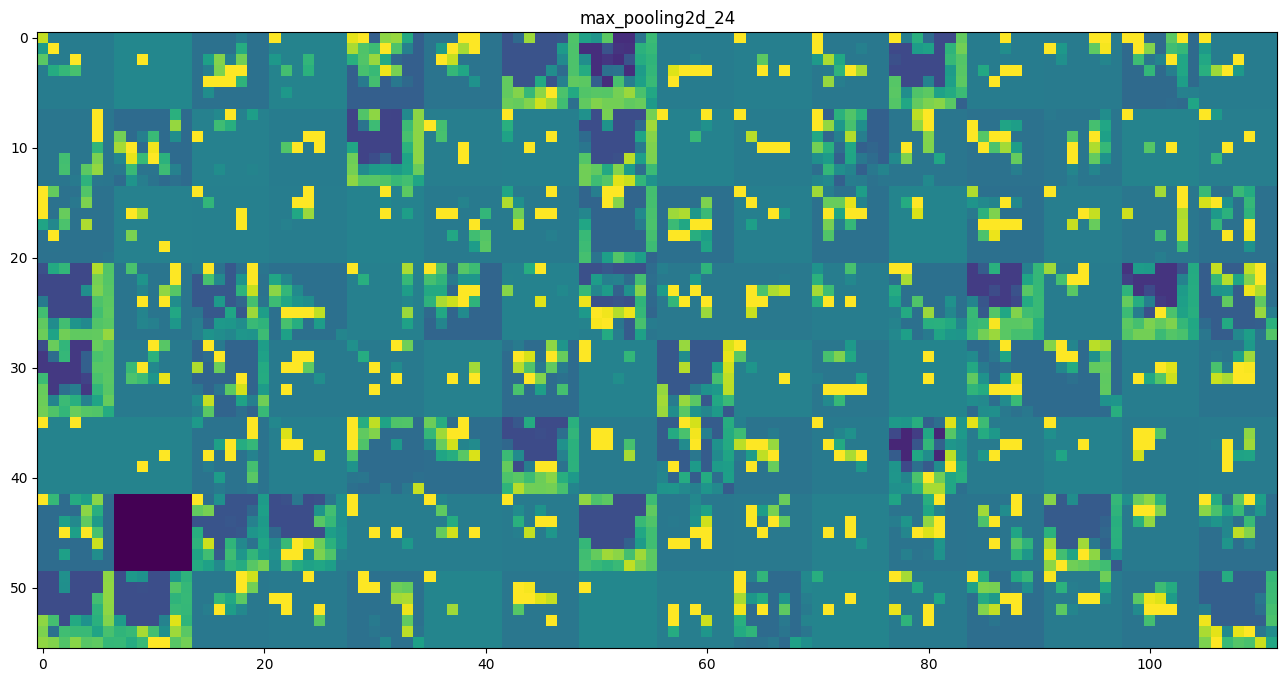

In [35]:
#Visualizing every channel in every intermediate activation

layer_names = []                                                        
for layer in model.layers[:8]:                                          
    layer_names.append(layer.name)                              

images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1] 

    size = layer_activation.shape[1]    

    n_cols = n_features // images_per_row                           
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            channel_image -= channel_image.mean()  
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

In [36]:
#load VGG16 model
from keras.applications.vgg16 import VGG16
model = VGG16(weights='imagenet')

from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 225s 0us/step


In [43]:
#load image
img_path = 'elephant1.png'
img = image.load_img(img_path, target_size=(224, 224))

#create float32 Numpy array of shape (224, 224, 3)
x = image.img_to_array(img)

#Adds a dimension to transform the array into a batch of size
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

#make prediction for selected image
preds = model.predict(x)

# Try human-readable ImageNet labels; if offline, show class IDs + probabilities.
try:
    top3 = decode_predictions(preds, top=3)[0]
    print('most probably 3 classes:\n', top3)
except Exception as e:
    top3_idx = preds[0].argsort()[-3:][::-1]
    print('Could not download ImageNet label mapping (offline).')
    print('Top 3 class IDs and probabilities:')
    for idx in top3_idx:
        print(f'  class #{idx}: {preds[0][idx]:.6f}')
    print('Original error:', e)

# 386 is the number of the african elephant class
print('predicted class number:\n', np.argmax(preds[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Could not download ImageNet label mapping (offline).
Top 3 class IDs and probabilities:
  class #386: 0.888797
  class #101: 0.102238
  class #385: 0.008635
Original error: URL fetch failure on https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json: None -- [Errno 8] nodename nor servname provided, or not known
predicted class number:
 386


In [44]:
import tensorflow as tf

# Build a model that maps input image to the last conv layer output and predictions.
last_conv_layer = model.get_layer('block5_conv3')
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[last_conv_layer.output, model.output],
)

# Compute gradient of top predicted class wrt the last conv layer output.
pred_index = int(np.argmax(preds[0]))
with tf.GradientTape() as tape:
    conv_layer_output, predictions = grad_model(x)
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_layer_output)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_layer_output_value = conv_layer_output[0].numpy()
pooled_grads_value = pooled_grads.numpy()

# Weight each channel by how important it is for the predicted class.
for i in range(pooled_grads_value.shape[0]):
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]

# The channel-wise mean gives the Grad-CAM heatmap.
heatmap = np.mean(conv_layer_output_value, axis=-1)

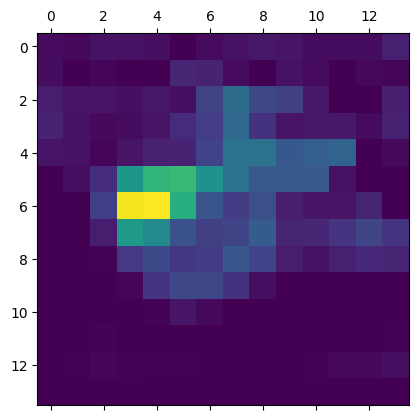

In [45]:
#Normalize values between 0 and 1
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
#Show heatmap
plt.matshow(heatmap)


The most informative area of the image is the head of small elephant.


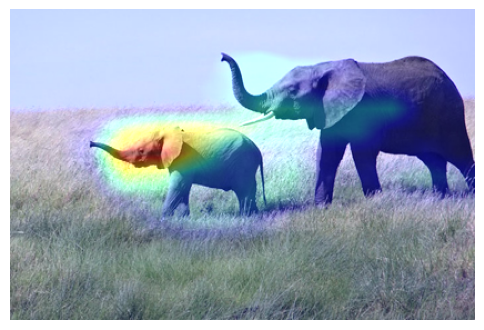

In [50]:
# OpenCV-free heatmap overlay (works offline with installed packages)
import numpy as np
from PIL import Image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img_name = 'elephant_heatmap.png'

# Load original image via PIL and ensure RGB float format in [0, 1]
img_pil = Image.open(img_path).convert('RGB')
img = np.asarray(img_pil).astype('float32') / 255.0

# Resize heatmap to image size
heatmap_safe = np.maximum(heatmap, 0)
if np.max(heatmap_safe) > 0:
    heatmap_safe = heatmap_safe / np.max(heatmap_safe)
heatmap_uint8 = np.uint8(255 * heatmap_safe)
heatmap_img = Image.fromarray(heatmap_uint8).resize((img.shape[1], img.shape[0]), Image.BILINEAR)
heatmap_resized = np.array(heatmap_img).astype('float32') / 255.0

# Apply JET colormap and blend
heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]
superimposed_img = np.clip(0.4 * heatmap_color + img, 0, 1)

# Save and show image
plt.imsave(img_name, superimposed_img)
img_out = mpimg.imread(img_name)
plt.figure(figsize=(6, 6))
plt.imshow(img_out)
plt.axis('off')
print("\nThe most informative area of the image is the head of small elephant.")